Vitesse limite pour un champ électrique nul:  0.00010526750276243095
Vitesse limite dans un champ électrique:  0.00010526656483274791
Champ pour une vitesse limite nulle:  224467.79255465826


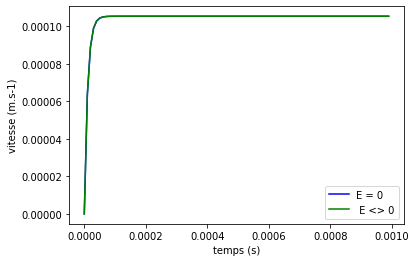

In [2]:
from scipy.integrate import odeint # on importe uniquement ce dont on a besoin
from pylab import *                # fonction de tracé de courbe

# paramètres physiques de l'expérience
eta  = 1.81e-5  # viscosité de l'air (en Pas.s à 293K)
rhoA = 1.29     # masse volumique de l'air (en kg.m-3 à 293K et 1013 hPa)
rhoH = 875.3    # masse volumique de l'huile (en kg.m-3 à 293K)
rg = 1e-6       # rayon de la gouttelette (en m)
q = 1.6e-19     # charge électrique portée par la gouttelette (1 e en Coulomb)
g = 9.81        # accélération de la pesanteur
Vg = (4 * pi * rg**3)/3  # volume de la gouttelette
m = Vg * rhoH           # masse de la gouttelette

# saisie de la valeur du champ électrique (en V.m-1)
E =  2.0 #input('Valeur du champ électrique (V.m-1): ')


# calcul des coefficents de l'équation différentielle
K = (6 * pi * eta * rg)/ m
C = (Vg*g*(rhoH - rhoA))/m - (q*E/m)

# definition de l'équation différentielle
def Millikan(v,t):
    return -K*v + C

# conditions initiales de l'expérience
t0 = 0.0
v0 = 0.0

# définition du vecteur temps de l'expérience
tmax = 0.001
pastemps = tmax/100
time = arange(t0, tmax, pastemps) # créé un vecteur de pastemps points entre t0 et tmax

# solution analytique
#vr = (C/K)*(1 - exp(-time*K))

# calcul de la vitesse limite en l'absence de champ électrique
vls = (Vg*g*(rhoH - rhoA))/(6 * pi * eta * rg)
print ('Vitesse limite pour un champ électrique nul: ',vls)

# calcul de la vitesse de chute avec champ électrique
ve = odeint(Millikan,v0,time)
vle = vls - q*E/(6 * pi * eta * rg)
print ('Vitesse limite dans un champ électrique: ',vle)
print ('Champ pour une vitesse limite nulle: ',
       vls*(6 * pi * eta * rg)/q)

# calcul de la vitesse de chute sans champ électrique
C = (Vg*g*(rhoH - rhoA))/m
vs = odeint(Millikan,v0,time)


# trace des résultats
figure()
plot(time,vs,'b-',label='E = 0')
#plot(time,vr,'r-',label='analytique')
plot (time,ve,'g-',label=' E <> 0')

xlabel('temps (s)')
ylabel('vitesse (m.s-1)')
legend(loc='best')
show()
